In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from msfm.utils import files

from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization, configuration
from deep_lss.nets.mlp import MultiLayerPerceptron

from msi.utils import dataset

2025-10-14 06:06:24.491420: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-14 06:06:24.491449: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-14 06:06:24.543915: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-14 06:06:24.665750: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-14 06:06:29.346540: W tensorflow/compiler/tf2

# configuration

In [3]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/marcel/simple.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/marcel"

n_side = msfm_conf["analysis"]["n_side"]

cosmo_params = ["Om", "s8", "w0"]
lensing_params = ["Aia", "n_Aia"]
clustering_params = ["bg", "n_bg"]

In [4]:
probe = "lensing"
# probe = "clustering"
# probe = "combined"

if probe == "lensing":
    params = cosmo_params + lensing_params
    n_z = 4
elif probe == "clustering":
    params = cosmo_params + clustering_params
    n_z = 4
elif probe == "combined":
    params = cosmo_params + lensing_params + clustering_params
    n_z = 8

# dataset

25-10-14 06:06:50 preprocessin INF   Loading the pre-binned Cls 
25-10-14 06:06:50 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/marcel 
25-10-14 06:06:50 input_output INF   Array shapes: 
25-10-14 06:06:50 input_output INF   fiducial/i_example = (33080,) 
25-10-14 06:06:50 input_output INF   fiducial/i_noise   = (33080,) 
25-10-14 06:06:51 input_output INF   fiducial/cls/binned = (33080, 32, 36) 
25-10-14 06:06:51 input_output INF   fiducial/cls/bin_edges = (33, 36) 
25-10-14 06:06:51 input_output INF   grid/cosmo         = (2500, 400, 12) 
25-10-14 06:06:51 input_output INF   grid/i_example     = (2500, 400) 
25-10-14 06:06:51 input_output INF   grid/i_noise       = (2500, 400) 
25-10-14 06:06:51 input_output INF   grid/i_sobol       = (2500, 400) 
25-10-14 06:06:54 input_output INF   grid/cls/binned    = (2500, 400, 32, 36) 
25-10-14 06:06:54 input_output INF   grid/cls/bin_edges = (2500, 33, 36) 
25-10-14 06:06:54 input_output INF   Done loading the sum

2025-10-14 06:07:03.693902: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


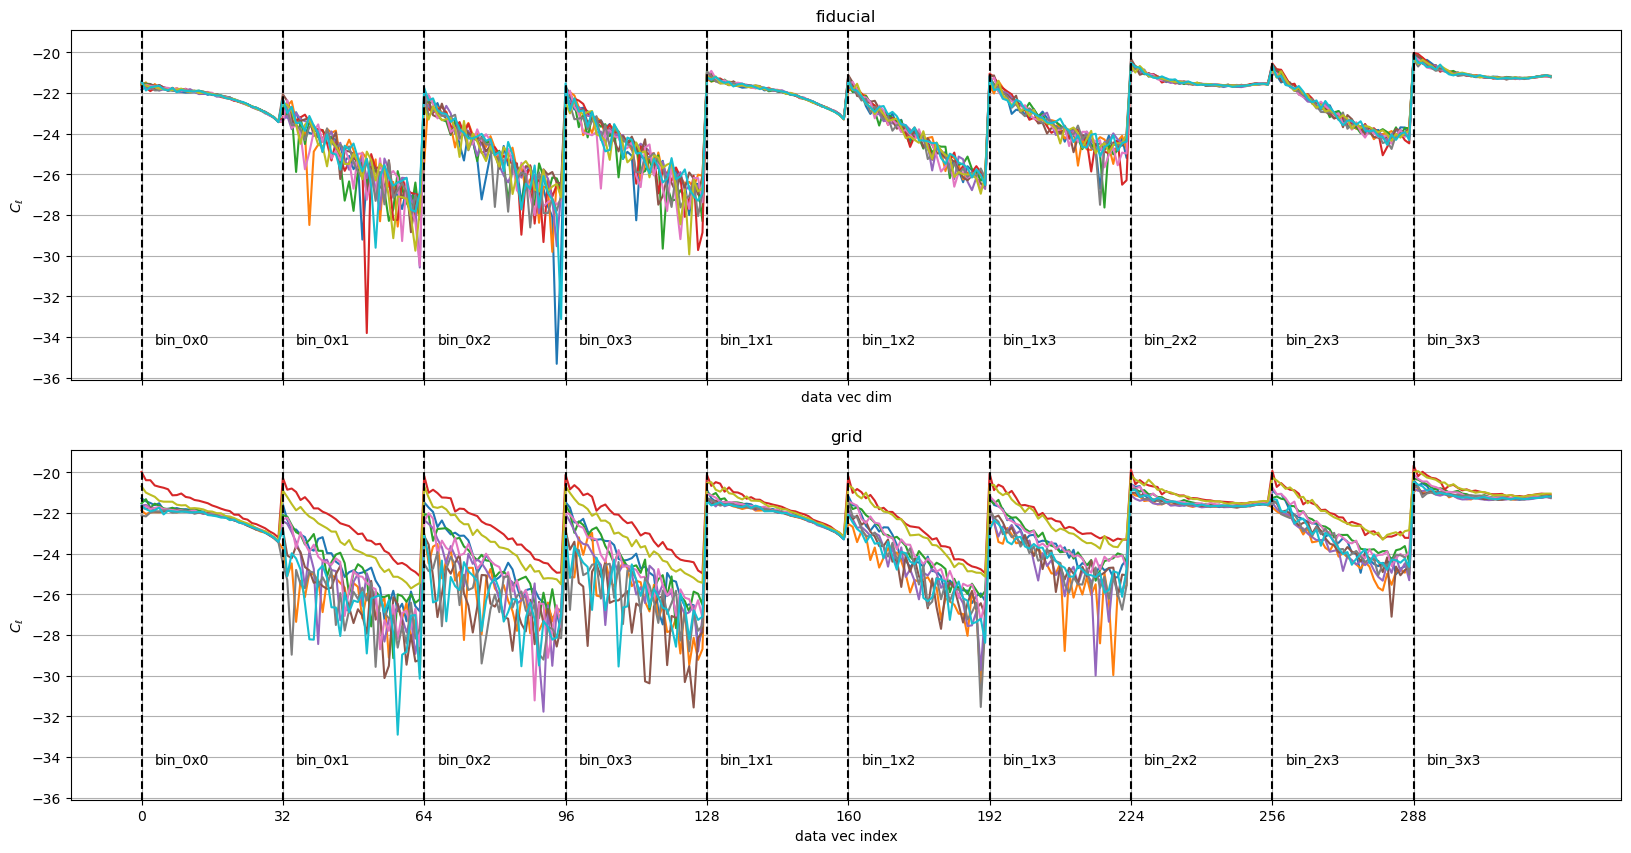

In [5]:
batch_size = 2**12
shuffle_buffer = 4*batch_size
apply_log = True
standardize = False
l_mins = [0.0] * 4
l_maxs = [3 * n_side] * 4
sigmas = [0.0] * n_z

cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    params=params,
    # selection
    probe=probe,
    with_gaussian_noise=False,
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # scales
    l_mins=l_mins,
    l_maxs=l_maxs,
    white_noise_sigmas=sigmas,
    # preprocessing
    apply_log=apply_log,
    standardize=standardize,
)

In [6]:
batch_size = 2**12
shuffle_buffer = 4*batch_size
apply_log = True
standardize = False

cosine_decay = False
n_steps = 100_000

out_dir = os.path.join(out_dir_base, "cls/mutual_info")
if with_lensing and not with_clustering:
    out_dir = os.path.join(out_dir, "lensing")
elif with_clustering and not with_lensing:
    out_dir = os.path.join(out_dir, "clustering")
elif with_lensing and with_clustering:
    out_dir = os.path.join(out_dir, "combined")
out_dir = os.path.join(out_dir, f"standard={standardize},log={apply_log},steps={n_steps}")

# label += "_lmin=113" 
    
if label is not None:
    out_dir = os.path.join(out_dir, label)
os.makedirs(out_dir, exist_ok=True)

print("base_dir = ", base_dir)
print("out_dir = ", out_dir)

NameError: name 'out_dir_base' is not defined

In [ ]:
bins = power_spectra.get_cl_bins(
    msfm_conf["analysis"]["power_spectra"]["l_min"], 
    msfm_conf["analysis"]["power_spectra"]["l_max"], 
    msfm_conf["analysis"]["power_spectra"]["n_bins"]
)
print(bins[-28:])

In [ ]:
cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_gaussian_noise=True,
    # keep_last_i_bins=28,
    # bin_indices=[bin_index],
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # smoothing not from the dlss_conf
    # theta_fwhms=theta_fwhm,
    # white_noise_sigmas=white_noise_sigma,
    # cls_from_maps=True,
    # preprocessing
    apply_log=apply_log,
    standardize=standardize,
)

# hard cut dset

In [ ]:
# l_mins = [0.0] * 4
# l_maxs = [3 * n_side] * 4

# cl_dset_train, cl_dset_test, out_dict, scaler, pca = dataset.get_binned_power_spectra_dset_legacy(
#     base_dir, 
#     # configuration
#     msfm_conf=msfm_conf, 
#     params=params,
#     # selection
#     with_lensing=True,
#     with_clustering=True,
#     # dset
#     batch_size=batch_size,
#     shuffle_buffer=shuffle_buffer,
#     # power spectra
#     l_mins=l_mins,
#     l_maxs=l_maxs,
#     n_bins=32,
#     fixed_binning=False,
#     # additional preprocessing
#     apply_log=apply_log,
#     standardize=standardize,
# )